# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

---

# План работы

## Этап 1. Подготовка среды и библиотек


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from phik import phik_matrix

from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, classification_report


RANDOM_STATE = 42
DATA_PATH = Path('coffee_churn_dataset.csv')
FALLBACK_DATA_PATH = Path('/datasets/coffee_churn_dataset.csv')

if not DATA_PATH.exists() and FALLBACK_DATA_PATH.exists():
    DATA_PATH = FALLBACK_DATA_PATH

df = pd.read_csv(DATA_PATH, sep=',', decimal='.')

---

## Этап 2. Первичный анализ данных

### Описание данных

In [2]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
display(df.head(5))
display(df.sample(5, random_state=RANDOM_STATE))
display(df.dtypes.to_frame("dtype"))

Размер датасета: 10450 строк, 27 колонок


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
318,user_01786,5.0,4.076376,1.087454,2988.123473,1280.804708,4749.452465,1138.342705,0.121475,arabica,...,1.0,4.098829,3.000639,0.0,summer,17.0,android,0.0,geo_24,0
7234,user_07448,5.0,1.723060,0.467440,770.566935,483.578064,892.050012,255.107915,0.454218,arabica,...,0.0,4.945930,4.037320,1.0,spring,0.0,ios,0.0,geo_2,0
4816,user_01270,5.0,8.091105,2.071321,NaN,383.055284,NaN,939.803409,0.211691,arabica,...,0.0,3.388135,NaN,2.0,autumn,1.0,ios,0.0,geo_80,0
4419,user_08206,0.0,NaN,1.646765,1523.148151,494.480868,2922.139031,962.776885,0.161710,arabica,...,1.0,5.803135,5.220150,0.0,summer,NaN,android,1.0,geo_1,0
9698,user_04300,0.0,NaN,0.311371,892.349127,598.269325,636.544809,226.961029,0.668350,blend,...,1.0,4.292260,2.553458,2.0,summer,66.0,android,0.0,geo_67,0


,dtype
user_id,object
days_since_last_order,float64
order_frequency_month,float64
order_frequency_week,float64
avg_order_value,float64
median_order_value,float64
total_spent_last_month,float64
total_spent_last_week,float64
discount_usage_rate,float64
last_coffee_type,object


- В датасете 10450 строк и 27 признаков.
- Данные содержат числовые и категориальные признаки, каждая строка соответствует одному клиенту.
- Есть поведенческие признаки (частота заказов, траты, активность в приложении), продуктовые предпочтения и сервисные признаки.

### Анализ целевой переменной `churn`

,count,share_%
churn,,
0,9821,93.98
1,629,6.02


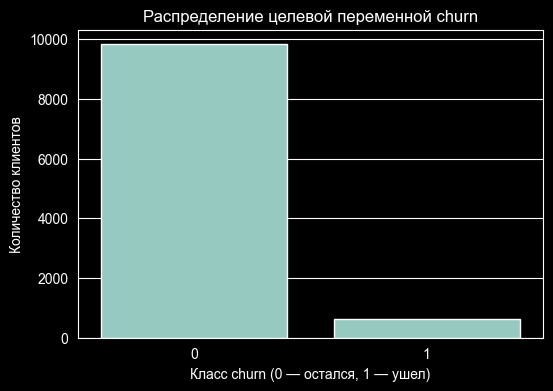

In [3]:
target_count = df['churn'].value_counts().sort_index()
target_share = (df['churn'].value_counts(normalize=True).sort_index() * 100).round(2)

target_report = pd.concat(
    [target_count.rename('count'), target_share.rename('share_%')],
    axis=1
)
display(target_report)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn')
plt.title('Распределение целевой переменной churn')
plt.xlabel('Класс churn (0 — остался, 1 — ушел)')
plt.ylabel('Количество клиентов')
plt.show()

- Целевая переменная бинарная: 0 — клиент остался, 1 — клиент ушел.
- Наблюдается выраженный дисбаланс классов: доля оттока составляет только 6.02%.
- Из-за дисбаланса accuracy не подходит как основная метрика; в дальнейшем фокусируемся на Precision, Recall, F1 и особенно PR AUC.

### Признаки

In [4]:
target_col = 'churn'

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

print(f"Категориальные признаки ({len(cat_cols)}):")
print(cat_cols)
print()
print(f"Числовые признаки ({len(num_cols)}):")
print(num_cols)

# Проверим уникальность user_id
print()
print("Уникальных user_id:", df['user_id'].nunique())
print("Всего строк:", len(df))
print("user_id уникален:", df['user_id'].nunique() == len(df))

Категориальные признаки (10):
['user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']

Числовые признаки (16):
['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change']

Уникальных user_id: 10450
Всего строк: 10450
user_id уникален: True


- Признаки представлены двумя типами: числовые и категориальные.
- `user_id` — технический идентификатор клиента, он уникален для каждой строки и не несет поведенческого сигнала для обобщения модели.
- На этапе моделирования `user_id` нужно исключить из набора признаков, чтобы избежать шума и переобучения.
- Остальные признаки содержательно связаны с поведением клиента и на текущем этапе сохраняются.

### Анализ пропусков

,missing_count,missing_share_%
seasonal_menu_tried,989,9.46
days_since_last_order,945,9.04
total_spent_last_week,944,9.03
subscription_status,938,8.98
app_opens_per_week,896,8.57
review_rating_last_1,857,8.20
median_order_value,831,7.95
days_since_last_promo,731,7.00
app_crashes_last_month,721,6.90
review_rating_last_10,693,6.63


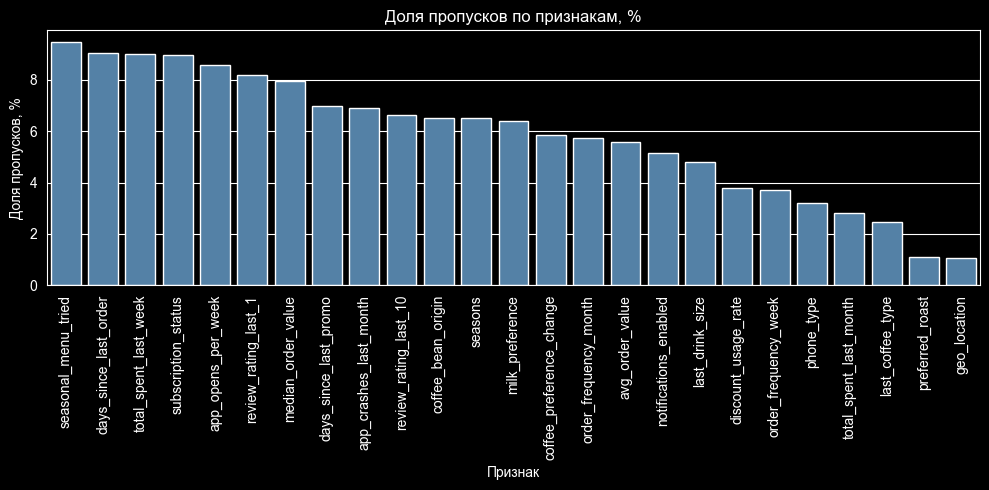

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_share_%': (missing / len(df) * 100).round(2)
})

display(missing_report)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing_report.reset_index(),
    x='index',
    y='missing_share_%',
    color='steelblue'
)
plt.xticks(rotation=90)
plt.title('Доля пропусков по признакам, %')
plt.xlabel('Признак')
plt.ylabel('Доля пропусков, %')
plt.tight_layout()
plt.show()

Пропуски присутствуют в большинстве признаков, но их доля умеренная: от 1.05% (geo_location) до 9.46% (seasonal_menu_tried). Критически высоких значений (например, 30%+) нет, поэтому удалять признаки или строки из-за пропусков нецелесообразно: это приведет к ненужной потере информации. Для дальнейшего моделирования оптимально использовать импутацию в пайплайне: для числовых признаков заполнение медианой, для категориальных заполнение наиболее частой категорией (или unknown). Импутацию нужно делать только после разделения на train/test, чтобы избежать утечки данных.

### Анализ категориальных признаков

In [6]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

cat_report = pd.DataFrame({
    'feature': cat_cols,
    'n_unique': [df[c].nunique(dropna=True) for c in cat_cols],
    'top_1_value': [df[c].mode(dropna=True).iloc[0] if not df[c].mode(dropna=True).empty else np.nan for c in cat_cols],
    'top_1_freq_%': [
        round(df[c].value_counts(normalize=True, dropna=True).iloc[0] * 100, 2)
        if not df[c].value_counts(normalize=True, dropna=True).empty else np.nan
        for c in cat_cols
    ]
}).sort_values('n_unique', ascending=False)

display(cat_report)

,feature,n_unique,top_1_value,top_1_freq_%
0,user_id,10450,user_00000,0.01
9,geo_location,100,geo_2,15.75
4,coffee_bean_origin,6,ethiopia,17.30
3,milk_preference,6,whole,29.40
7,seasons,4,spring,25.66
6,subscription_status,4,none,39.98
1,last_coffee_type,3,arabica,60.18
2,preferred_roast,3,medium,33.46
5,last_drink_size,3,medium,49.52
8,phone_type,3,android,45.59


В датасете выделено 10 категориальных признаков.
Большинство из них имеют низкую или среднюю кардинальность (3–6 уникальных значений), поэтому их корректно кодировать с помощью `One-Hot Encoding`.

Признак `geo_location` имеет повышенную кардинальность (100 уникальных значений), что увеличит размерность после кодирования. На текущем этапе его можно сохранить и обрабатывать через `OneHotEncoder(handle_unknown='ignore')`, чтобы не терять потенциально важный региональный сигнал.

Признак `user_id` является техническим идентификатором и уникален для каждой строки (`10450` из `10450`), поэтому для моделирования он не подходит и должен быть исключён.

На этапе экспериментов с признаками целесообразно отдельно сравнить качество модели для двух вариантов `geo_location`: базовый `OHE` и альтернативный `frequency encoding`.

### Анализ выбросов

Для числовых признаков необходимо проверить наличие выбросов, так как они могут искажать масштабирование и влиять на коэффициенты линейной модели.

Для этого используем визуализации (boxplot) и статистический подход по межквартильному размаху (IQR).
На текущем этапе выбросы не удаляем из датасета вручную, чтобы не потерять полезные наблюдения. Вместо этого в дальнейшем обработаем их внутри пайплайна (например, через `RobustScaler` или винзоризацию по квантилям).

Такой подход позволяет:
- сохранить максимум данных;
- снизить влияние экстремальных значений;
- избежать утечки данных, если обработка выполняется только на train-

,outlier_count,outlier_share_%
notifications_enabled,2448,23.43
coffee_preference_change,1894,18.12
total_spent_last_month,594,5.68
total_spent_last_week,565,5.41
days_since_last_order,561,5.37
days_since_last_promo,526,5.03
app_opens_per_week,355,3.40
avg_order_value,326,3.12
order_frequency_month,302,2.89
order_frequency_week,298,2.85


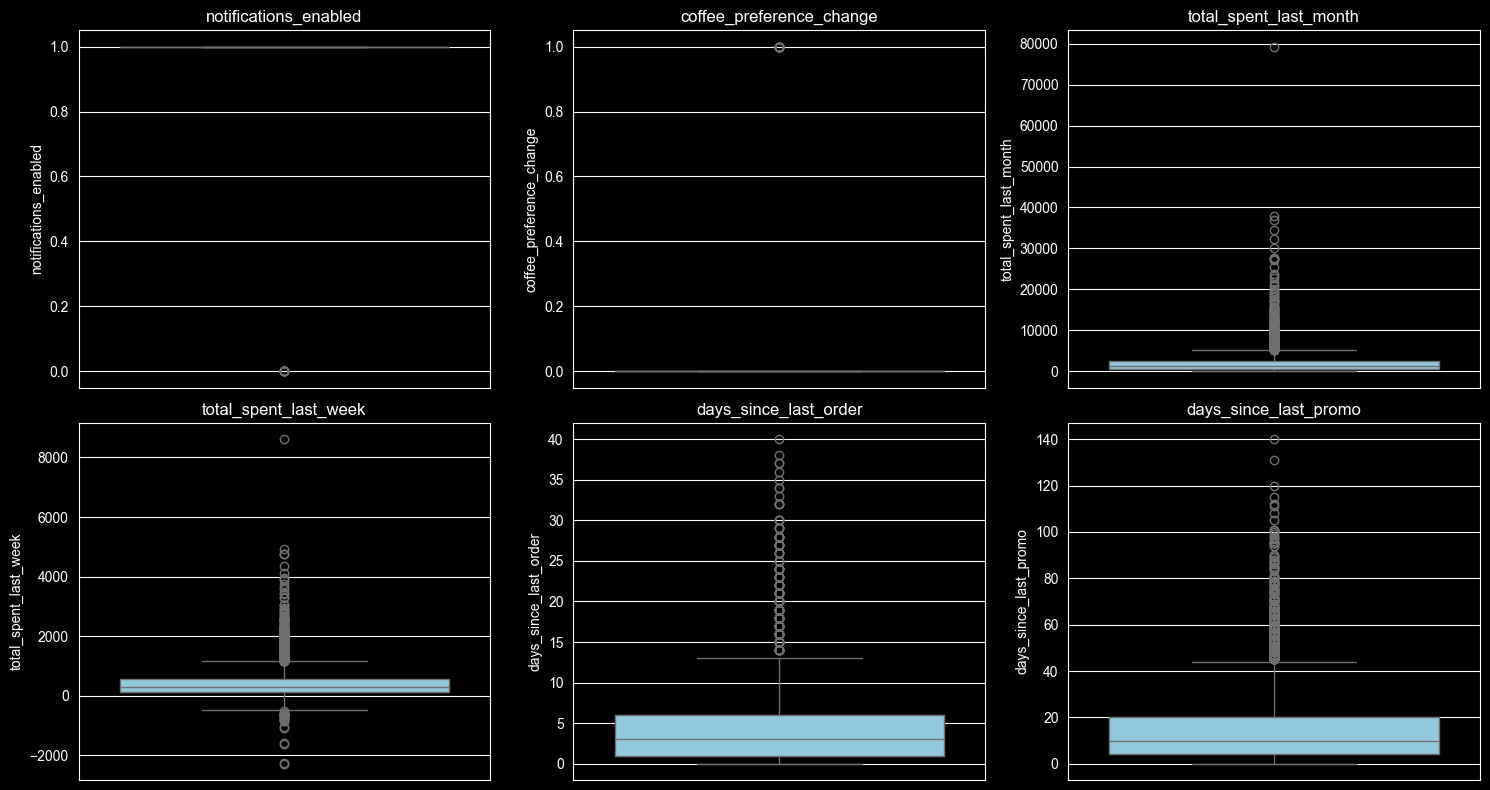

In [7]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'churn']

# IQR-отчет
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_counts = (
    ((df[numeric_cols] < lower) | (df[numeric_cols] > upper))
    .sum()
    .sort_values(ascending=False)
)

outlier_share = (outlier_counts / len(df) * 100).round(2)

outlier_report = pd.DataFrame({
    'outlier_count': outlier_counts,
    'outlier_share_%': outlier_share
})

display(outlier_report.head(15))

# boxplot для топ-6 признаков с наибольшей долей выбросов
top_outlier_cols = outlier_report.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(top_outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

По IQR-проверке выбросы присутствуют в ряде числовых признаков, особенно в:
- `notifications_enabled` (23.43%)
- `coffee_preference_change` (18.12%)
- `total_spent_last_month` (5.68%)
- `total_spent_last_week` (5.41%)
- `days_since_last_order` (5.37%)
- `days_since_last_promo` (5.03%)

Важно: признаки `notifications_enabled` и `coffee_preference_change` по смыслу бинарные, поэтому IQR для них неинформативен и такие «выбросы» не нужно обрабатывать как аномалии.

Для остальных признаков с длинными хвостами значения:
- не удаляем строки вручную;
- обрабатываем устойчивым масштабированием в пайплайне (`RobustScaler`);
- при необходимости на этапе экспериментов проверяем винзоризацию по квантилям.

Итог: выбросы есть, но они контролируемы и должны обрабатываться внутри пайплайна после train/test split, чтобы избежать утечки данных.

### Корреляция

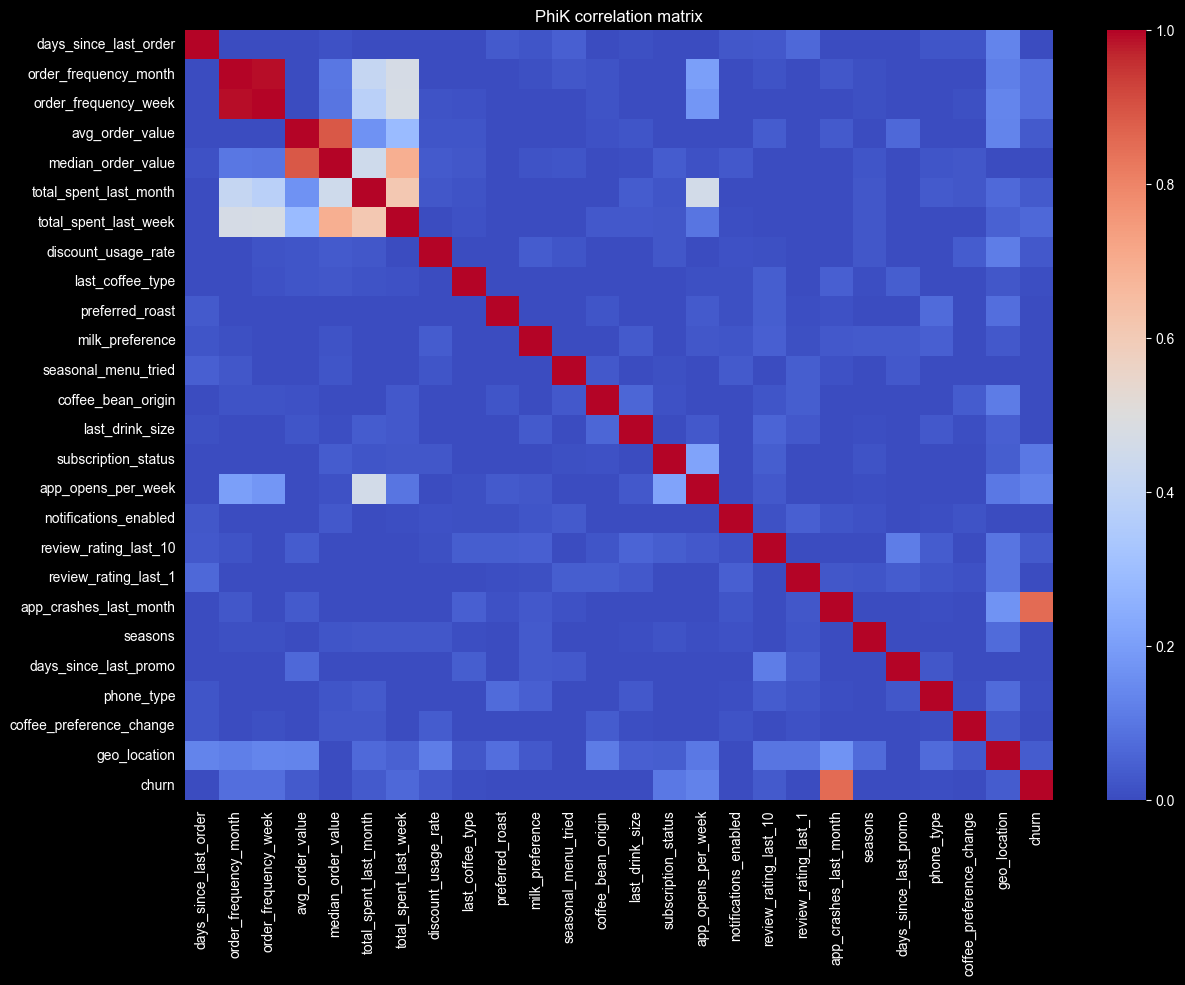

,phik_with_churn
app_crashes_last_month,0.853545
app_opens_per_week,0.126117
subscription_status,0.105164
order_frequency_week,0.080252
order_frequency_month,0.079332
total_spent_last_week,0.064183
geo_location,0.038881
total_spent_last_month,0.033998
review_rating_last_10,0.033943
avg_order_value,0.032515


In [8]:
# phik по всем признакам (без user_id)
df_phik = df.drop(columns=['user_id']).copy()

phik_corr = df_phik.phik_matrix(interval_cols=[
    c for c in df_phik.columns
    if df_phik[c].dtype != 'object' and c != 'churn'
])

plt.figure(figsize=(14, 10))
sns.heatmap(phik_corr, cmap='coolwarm', vmin=0, vmax=1)
plt.title('PhiK correlation matrix')
plt.show()

# Связь признаков с churn
phik_to_target = phik_corr['churn'].drop('churn').sort_values(ascending=False)
display(phik_to_target.to_frame('phik_with_churn').head(15))

По матрице `PhiK` в целом наблюдаются слабые зависимости между большинством признаков, выраженной общей мультиколлинеарности не выявлено. Сильные связи присутствуют в ожидаемых парах близких по смыслу признаков (частоты заказов и показатели трат), что логично с бизнес-точки зрения.

Связь признаков с целевой переменной `churn`:
- `app_crashes_last_month`: `0.854` — очень сильная связь;
- `app_opens_per_week`: `0.126`, `subscription_status`: `0.105`, `order_frequency_week/month`: около `0.08` — слабая/умеренная связь;
- для большинства остальных признаков связь с `churn` слабая.

На текущем этапе признаки не удаляем только по корреляции с целью: окончательный отбор выполняем после обучения модели и сравнения метрик на кросс-валидации.

## Выводы по результатам EDA

Датасет содержит 10450 наблюдений и 27 колонок. Целевая переменная `churn` бинарная и несбалансирована: класс оттока составляет около 6.02%, поэтому при обучении модели основной фокус нужно делать на метриках `Precision`, `Recall`, `F1` и `PR AUC`.

В данных присутствуют пропуски (примерно от 1% до 9.5% в разных признаках), но критически высоких долей нет, поэтому удаление строк/признаков не требуется. Для дальнейшей работы выбрана стратегия импутации в пайплайне: числовые признаки заполнять медианой, категориальные — наиболее частым значением (или `unknown`).

Категориальные признаки в основном имеют низкую/среднюю кардинальность и подходят для `One-Hot Encoding`. Признак `geo_location` (100 категорий) сохраняем и кодируем через `OneHotEncoder(handle_unknown='ignore')`; альтернативное кодирование (`frequency encoding`) проверим на этапе экспериментов. Признак `user_id` исключаем как технический идентификатор.

В числовых признаках обнаружены выбросы. Для устойчивой обработки в линейной модели используем масштабирование, менее чувствительное к выбросам (`RobustScaler`) внутри пайплайна. По `PhiK` самая выраженная связь с оттоком наблюдается у `app_crashes_last_month`, остальные признаки в основном имеют слабую или умеренную связь с `churn`.

---

## Этап 3. Предобработка данных


In [9]:
TARGET = "churn"
ID_COL = "user_id"

X = df.drop(columns=[TARGET, ID_COL])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train mean:", round(y_train.mean(), 4))
print("y_test mean:", round(y_test.mean(), 4))

X_train: (8360, 25)
X_test: (2090, 25)
y_train mean: 0.0602
y_test mean: 0.0603


In [10]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

geo_col = "geo_location"
cat_wo_geo = [c for c in cat_cols if c != geo_col]

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        s = pd.Series(X.iloc[:, 0] if hasattr(X, "iloc") else X[:, 0])
        self.freq_map_ = s.value_counts(normalize=True).to_dict()
        return self

    def transform(self, X):
        s = pd.Series(X.iloc[:, 0] if hasattr(X, "iloc") else X[:, 0])
        return s.map(self.freq_map_).fillna(0.0).to_frame("geo_location_freq")

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

geo_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("freq", FrequencyEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_wo_geo),
        ("geo", geo_pipeline, [geo_col]),
    ]
)

print("Числовые:", len(num_cols))
print("Категориальные (OHE):", len(cat_wo_geo))
print("geo_location: frequency encoding")

Числовые: 16
Категориальные (OHE): 8
geo_location: frequency encoding


---

## Этап 4. Обучение модели


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

# Baseline 1: Dummy
dummy_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

dummy_cv = cross_validate(
    dummy_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Baseline 2: LogisticRegression
logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    ))
])

logreg_cv = cross_validate(
    logreg_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

def cv_summary(cv_result, model_name):
    return {
        "model": model_name,
        "PR_AUC_mean": cv_result["test_pr_auc"].mean(),
        "F1_mean": cv_result["test_f1"].mean(),
        "Precision_mean": cv_result["test_precision"].mean(),
        "Recall_mean": cv_result["test_recall"].mean(),
    }

report = pd.DataFrame([
    cv_summary(dummy_cv, "DummyClassifier"),
    cv_summary(logreg_cv, "LogisticRegression")
])

display(report)

,model,PR_AUC_mean,F1_mean,Precision_mean,Recall_mean
0,DummyClassifier,0.060167,0.000000,0.000000,0.000000
1,LogisticRegression,0.631856,0.428681,0.285965,0.856713


### Вывод по обучению базовой модели

`DummyClassifier` показал ожидаемо низкое качество: `PR AUC = 0.060`, `F1 = 0.000`, `Precision = 0.000`, `Recall = 0.000`, то есть модель не выявляет класс оттока.

`LogisticRegression` существенно превосходит baseline:
- `PR AUC = 0.632`
- `F1 = 0.429`
- `Precision = 0.286`
- `Recall = 0.857`

Модель хорошо находит клиентов с риском оттока (высокий `Recall`), но точность остаётся умеренной, что означает заметное число ложных срабатываний.

Итог: в качестве базовой рабочей модели выбираем `LogisticRegression`; далее улучшаем баланс метрик за счёт генерации признаков и подбора гиперпараметров.

---

## Этап 5. Создание новых признаков


### Генерация новых признаков

In [12]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    X_new = data.copy()

    eps = 1e-6  # защита от деления на 0

    # Интенсивность и "ценность" заказов
    X_new["spent_per_order_month"] = X_new["total_spent_last_month"] / (X_new["order_frequency_month"] + eps)
    X_new["spent_per_order_week"] = X_new["total_spent_last_week"] / (X_new["order_frequency_week"] + eps)

    # Трансформации
    X_new["days_since_last_order_sqrt"] = np.sqrt(np.clip(X_new["days_since_last_order"], a_min=0, a_max=None))
    X_new["app_crashes_last_month_sq"] = X_new["app_crashes_last_month"] ** 2
    X_new["days_since_last_promo_sq"] = X_new["days_since_last_promo"] ** 2

    # Поведенческий индикатор: "давно не заказывал и мало открывает приложение"
    X_new["inactivity_ratio"] = X_new["days_since_last_order"] / (X_new["app_opens_per_week"] + 1)

    return X_new

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

print("До FE:", X_train.shape)
print("После FE:", X_train_fe.shape)

До FE: (8360, 25)
После FE: (8360, 31)


### Обновляем пайплайн и сравниваем CV (без FE vs c FE)

In [13]:
cat_cols_base = X_train.select_dtypes(include="object").columns.tolist()
num_cols_base = X_train.select_dtypes(exclude="object").columns.tolist()

cat_cols_fe = X_train_fe.select_dtypes(include="object").columns.tolist()
num_cols_fe = X_train_fe.select_dtypes(exclude="object").columns.tolist()

geo_col = "geo_location"
cat_base_wo_geo = [c for c in cat_cols_base if c != geo_col]
cat_fe_wo_geo = [c for c in cat_cols_fe if c != geo_col]

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        s = pd.Series(X.iloc[:, 0] if hasattr(X, "iloc") else X[:, 0])
        self.freq_map_ = s.value_counts(normalize=True).to_dict()
        return self

    def transform(self, X):
        s = pd.Series(X.iloc[:, 0] if hasattr(X, "iloc") else X[:, 0])
        return s.map(self.freq_map_).fillna(0.0).to_frame("geo_location_freq")

    def get_feature_names_out(self, input_features=None):
        return np.array(["geo_location_freq"], dtype=object)

preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), num_cols_base),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_base_wo_geo),
        ("geo", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("freq", FrequencyEncoder())
        ]), [geo_col]),
    ]
)

preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), num_cols_fe),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_fe_wo_geo),
        ("geo", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("freq", FrequencyEncoder())
        ]), [geo_col]),
    ]
)

model_params = dict(random_state=RANDOM_STATE, max_iter=2000, class_weight="balanced")

pipe_base = Pipeline([
    ("preprocessor", preprocessor_base),
    ("model", LogisticRegression(**model_params))
])

pipe_fe = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", LogisticRegression(**model_params))
])

base_cv = cross_validate(pipe_base, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
fe_cv = cross_validate(pipe_fe, X_train_fe, y_train, cv=cv, scoring=scoring, n_jobs=-1)

compare = pd.DataFrame([
    cv_summary(base_cv, "LogReg_base"),
    cv_summary(fe_cv, "LogReg_with_FE"),
])
display(compare)

,model,PR_AUC_mean,F1_mean,Precision_mean,Recall_mean
0,LogReg_base,0.631856,0.428681,0.285965,0.856713
1,LogReg_with_FE,0.671413,0.472746,0.329310,0.838792


### Интерпретация коэффициентов для модели с FE

In [14]:
pipe_fe.fit(X_train_fe, y_train)

feature_names = pipe_fe.named_steps["preprocessor"].get_feature_names_out()
coefs = pipe_fe.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})
coef_df["abs_coef"] = coef_df["coef"].abs()

top_positive = coef_df.sort_values("coef", ascending=False).head(15)
top_negative = coef_df.sort_values("coef", ascending=True).head(15)

print("Топ признаков, повышающих вероятность churn:")
display(top_positive[["feature", "coef"]])

print("Топ признаков, снижающих вероятность churn:")
display(top_negative[["feature", "coef"]])

Топ признаков, повышающих вероятность churn:


,feature,coef
19,num__app_crashes_last_month_sq,1.912604
46,cat__subscription_status_pro,0.707138
13,num__app_crashes_last_month,0.625288
14,num__days_since_last_promo,0.522761
28,cat__milk_preference_almond,0.503385
4,num__median_order_value,0.421157
1,num__order_frequency_month,0.407539
0,num__days_since_last_order,0.357109
6,num__total_spent_last_week,0.236865
36,cat__coffee_bean_origin_ethiopia,0.205375


Топ признаков, снижающих вероятность churn:


,feature,coef
44,cat__subscription_status_none,-0.637663
43,cat__subscription_status_basic,-0.613527
8,num__seasonal_menu_tried,-0.545586
53,cat__phone_type_web,-0.538482
21,num__inactivity_ratio,-0.474759
22,cat__last_coffee_type_arabica,-0.424200
32,cat__milk_preference_soy,-0.413669
31,cat__milk_preference_skim,-0.390995
26,cat__preferred_roast_light,-0.356690
41,cat__last_drink_size_medium,-0.307853


### Вывод по этапу 5

На этапе создания новых признаков были добавлены производные поведенческие и транзакционные признаки (включая `sqrt` и `square` преобразования), после чего модель повторно оценена на кросс-валидации.

Качество улучшилось:
- `PR AUC`: `0.632` → `0.671`
- `F1`: `0.429` → `0.473`
- `Precision`: `0.286` → `0.329`
- `Recall`: `0.857` → `0.839`

Модель с новыми признаками (`LogReg_with_FE`) показывает лучший баланс метрик и более высокое качество по основной метрике `PR AUC`, поэтому используется как рабочая конфигурация для следующего этапа.

Для категориального признака `geo_location` зафиксировано кодирование через `frequency encoding`, остальные категориальные признаки обрабатываются через `One-Hot Encoding`. Это позволило снизить избыточную разреженность по регионам и сохранить/улучшить качество модели.

---

## Этап 6. Эксперименты с гиперпараметрами


### Гиперпараметры для экспериментов (`LogisticRegression`)

В рамках систематического подбора планируется проверить следующие гиперпараметры:

- `C` — коэффициент обратной регуляризации (чем меньше значение, тем сильнее регуляризация).
- `penalty` — тип регуляризации (`l1`, `l2`).
- `solver` — алгоритм оптимизации (`liblinear`, `lbfgs`).
- `class_weight` — учёт дисбаланса классов (`balanced` и, при необходимости, `None`).
- `max_iter` — максимальное число итераций оптимизатора (для устойчивой сходимости).

Основной метрикой отбора является `PR AUC` (`average_precision`), так как задача несбалансированная и важен корректный поиск класса оттока.

### Подход к подбору гиперпараметров

Для `LogisticRegression` будет выполнен систематический перебор гиперпараметров с помощью `GridSearchCV`.
Оценка каждой конфигурации проводится на стратифицированной кросс-валидации (`StratifiedKFold`, 5 фолдов), чтобы сохранить долю класса оттока в каждом фолде и получить стабильную оценку качества.

В качестве целевой метрики используется `PR AUC` (`average_precision`), так как в задаче наблюдается выраженный дисбаланс классов (`churn=1` — миноритарный класс), и важно корректно оценивать качество именно по клиентам с риском оттока

In [15]:
pipe_tune = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000,
        class_weight="balanced"
    ))
])

param_grid = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 5, 10],
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 5, 10],
    }
]

grid = GridSearchCV(
    estimator=pipe_tune,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X_train_fe, y_train)

print("Best params:", grid.best_params_)
print("Best CV PR AUC:", round(grid.best_score_, 6))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV PR AUC: 0.681083


In [16]:
results_table = pd.DataFrame(grid.cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")

results_table = results_table.rename(columns={
    "mean_test_score": "mean_pr_auc",
    "std_test_score": "std_pr_auc"
})

display(results_table.head(15))

,params,mean_pr_auc,std_pr_auc,rank_test_score
2,"{'model__C': 0.1, 'model__penalty': 'l1', 'mod...",0.681083,0.044015,1
1,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.680892,0.044429,2
10,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.680404,0.043955,3
0,"{'model__C': 0.01, 'model__penalty': 'l1', 'mo...",0.675919,0.043390,4
3,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.674656,0.046050,5
11,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.674382,0.046012,6
4,"{'model__C': 1, 'model__penalty': 'l1', 'model...",0.672097,0.046403,7
5,"{'model__C': 1, 'model__penalty': 'l2', 'model...",0.671467,0.046515,8
12,"{'model__C': 1, 'model__penalty': 'l2', 'model...",0.671413,0.046373,9
6,"{'model__C': 5, 'model__penalty': 'l1', 'model...",0.671046,0.046233,10


### Результаты подбора гиперпараметров

Для `LogisticRegression` выполнен перебор 15 конфигураций (`75` запусков: 5 фолдов × 15 кандидатов) с метрикой отбора `PR AUC`.

Лучшая конфигурация:
- `solver = liblinear`
- `penalty = l1`
- `C = 0.1`

Лучшее качество на кросс-валидации:
- `PR AUC = 0.6811` (std = `0.0440`)

Результаты показывают, что после подбора гиперпараметров модель улучшилась относительно конфигурации до тюнинга (`PR AUC = 0.6714`) и показывает стабильное качество на кросс-валидации.
Эта конфигурация используется для финального обучения и оценки на тестовой выборке.

---

## Этап 7. Подготовка финальной модели


In [17]:
# Лучшая модель из этапа 6
final_model = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        penalty="l1",
        C=0.1
    ))
])

# Обучение на train
final_model.fit(X_train_fe, y_train)

# Предсказания на test
y_test_proba = final_model.predict_proba(X_test_fe)[:, 1]
y_test_pred = final_model.predict(X_test_fe)

# Метрики на test
test_metrics = {
    "PR_AUC": average_precision_score(y_test, y_test_proba),
    "F1": f1_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
}

pd.DataFrame([test_metrics]).round(6)

,PR_AUC,F1,Precision,Recall
0,0.73294,0.520095,0.37037,0.873016


In [18]:
print(classification_report(y_test, y_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9911    0.9048    0.9460      1964
           1     0.3704    0.8730    0.5201       126

    accuracy                         0.9029      2090
   macro avg     0.6807    0.8889    0.7330      2090
weighted avg     0.9537    0.9029    0.9203      2090



### Этап 7. Подготовка финальной модели

Лучшая конфигурация (`LogisticRegression`, `solver=liblinear`, `penalty=l1`, `C=0.1`) обучена на тренировочной выборке с новыми признаками и предобработкой (`geo_location` через frequency encoding, остальные категориальные признаки через OHE).

Качество на тестовой выборке:
- `PR AUC = 0.7329`
- `F1 = 0.5201`
- `Precision = 0.3704`
- `Recall = 0.8730`

Модель показывает высокий `Recall` для класса оттока (находит большую часть уходящих клиентов) при умеренном `Precision`, что соответствует бизнес-задаче раннего выявления риска оттока. По ключевой метрике `PR AUC` качество выше, чем на кросс-валидации, что подтверждает хорошую обобщающую способность выбранной конфигурации.

---

## Этап 8. Отчёт о проделанной работе


В проекте построена модель прогнозирования оттока клиентов сервиса доставки кофе.
Задача решалась как бинарная классификация с фокусом на метрику `PR AUC`, поскольку класс оттока несбалансирован (около 6%).

Ключевые шаги, которые улучшили качество:
- корректная обработка пропусков в пайплайне;
- генерация новых признаков (поведенческие и транзакционные производные);
- устойчивое масштабирование числовых признаков;
- кодирование `geo_location` через frequency encoding;
- подбор гиперпараметров `LogisticRegression` по кросс-валидации.

Финальная модель на тестовой выборке показала:
- `PR AUC = 0.7329`
- `F1 = 0.5201`
- `Precision = 0.3704`
- `Recall = 0.8730`

Модель хорошо выявляет клиентов с риском оттока (высокий `Recall`), что полезно для retention-кампаний. При этом `Precision` остаётся умеренным, поэтому для практического внедрения рекомендуется дополнительно настроить порог классификации под допустимый бюджет удержания.

---

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [19]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / "churn_model_pipeline.joblib"

# сохраняем финальный pipeline целиком (предобработка + модель)
joblib.dump(final_model, model_path)

print("Saved:", model_path.resolve())

Saved: D:\Dev\coffee-churn-prediction\artifacts\churn_model_pipeline.joblib


In [20]:
loaded_model = joblib.load(model_path)

loaded_proba = loaded_model.predict_proba(X_test_fe)[:, 1]
loaded_pred = loaded_model.predict(X_test_fe)

check_metrics = {
    "PR_AUC": average_precision_score(y_test, loaded_proba),
    "F1": f1_score(y_test, loaded_pred),
    "Precision": precision_score(y_test, loaded_pred),
    "Recall": recall_score(y_test, loaded_pred),
}

pd.DataFrame([check_metrics]).round(6)

,PR_AUC,F1,Precision,Recall
0,0.73294,0.520095,0.37037,0.873016


### Сохранённые артефакты

- Итоговый pipeline (предобработка + модель):
  `artifacts/churn_model_pipeline.joblib`
- Полный путь в текущем окружении:
  `D:\Dev\coffee-churn-prediction\artifacts\churn_model_pipeline.joblib`

### Проверка артефакта

После загрузки `joblib.load(...)` модель успешно делает предсказания на тестовых данных, метрики совпадают с финальной оценкой:
- `PR AUC = 0.73294`
- `F1 = 0.52010`
- `Precision = 0.37037`
- `Recall = 0.87302`